# Quantium Retail Analytics — Chip Category Analysis
## Notebook 2: Metric Calculation, Segment Analysis & Strategic Recommendation

**Analyst:** Amay

**Date:** April 2026  
**Input data:** quantium_clean_merged.csv (output from Notebook 1)  

### Context
This notebook builds on the cleaned and merged dataset from Notebook 1.
The goal is to define metrics, analyse customer segments, and form a
strategic recommendation for Julia the Category Manager ahead of the
upcoming chip category review.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.titlesize']    = 13
sns.set_palette("muted")

print("✓ Libraries loaded")

✓ Libraries loaded


In [2]:
# Load clean merge data
from google.colab import files

print("Upload quantium_clean_merged.csv from Notebook 1:")
uploaded = files.upload()

merged = pd.read_csv('quantium_clean_merged.csv', parse_dates=['DATE'])

print(f"\n✓ Data loaded: {merged.shape[0]:,} rows × {merged.shape[1]} columns")
print(f"  Date range:  {merged['DATE'].min().date()} → {merged['DATE'].max().date()}")
print(f"  Total sales: ${merged['TOT_SALES'].sum():,.2f}")
print(f"\nColumns: {merged.columns.tolist()}")

Upload quantium_clean_merged.csv from Notebook 1:


Saving quantium_clean_merged.csv to quantium_clean_merged.csv

✓ Data loaded: 246,739 rows × 13 columns
  Date range:  2018-07-01 → 2019-06-30
  Total sales: $1,805,171.70

Columns: ['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES', 'UNIT_PRICE', 'PACK_SIZE', 'BRAND', 'LIFESTAGE', 'PREMIUM_CUSTOMER']


In [3]:
# Define segment order for consistent chart ordering
# Fix display order for lifestage and premium tier across all charts
lifestage_order = [
    'YOUNG SINGLES/COUPLES',
    'YOUNG FAMILIES',
    'MIDAGE SINGLES/COUPLES',
    'OLDER FAMILIES',
    'OLDER SINGLES/COUPLES',
    'RETIREES',
    'NEW FAMILIES',
]

premium_order = ['Budget', 'Mainstream', 'Premium']

print("✓ Segment ordering defined")
print(f"  Lifestage groups:  {len(lifestage_order)}")
print(f"  Premium tiers:     {len(premium_order)}")

✓ Segment ordering defined
  Lifestage groups:  7
  Premium tiers:     3


In [4]:
# Calculate Segment Metrics
segment_summary = (merged
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(
        total_sales           = ('TOT_SALES',      'sum'),
        total_units           = ('PROD_QTY',       'sum'),
        num_customers         = ('LYLTY_CARD_NBR', 'nunique'),
        num_txns              = ('TXN_ID',         'nunique'),
        avg_unit_price        = ('UNIT_PRICE',     'mean'),
    )
    .reset_index()
    .round(2)
)

# Derived metrics
segment_summary['avg_spend_per_customer'] = (
    segment_summary['total_sales'] / segment_summary['num_customers']).round(2)

segment_summary['avg_units_per_txn'] = (
    segment_summary['total_units'] / segment_summary['num_txns']).round(2)

segment_summary['avg_txns_per_customer'] = (
    segment_summary['num_txns'] / segment_summary['num_customers']).round(2)

segment_summary['sales_pct'] = (
    segment_summary['total_sales'] / segment_summary['total_sales'].sum() * 100).round(2)

print("✓ Metrics calculated")
print(f"  Segments: {len(segment_summary)}")
display(segment_summary.sort_values('total_sales', ascending=False).reset_index(drop=True))

✓ Metrics calculated
  Segments: 21


,LIFESTAGE,PREMIUM_CUSTOMER,total_sales,total_units,num_customers,num_txns,avg_unit_price,avg_spend_per_customer,avg_units_per_txn,avg_txns_per_customer,sales_pct
0,OLDER FAMILIES,Budget,156863.75,41853,4611,21322,3.75,34.02,1.96,4.62,8.69
1,YOUNG SINGLES/COUPLES,Mainstream,147582.20,36225,7917,19482,4.07,18.64,1.86,2.46,8.18
2,RETIREES,Mainstream,145168.95,37677,6358,19878,3.84,22.83,1.90,3.13,8.04
3,YOUNG FAMILIES,Budget,129717.95,34482,3953,17629,3.76,32.82,1.96,4.46,7.19
4,OLDER SINGLES/COUPLES,Budget,127833.60,32883,4849,17078,3.88,26.36,1.93,3.52,7.08
5,OLDER SINGLES/COUPLES,Mainstream,124648.50,32607,4858,16958,3.81,25.66,1.92,3.49,6.91
6,OLDER SINGLES/COUPLES,Premium,123531.55,31693,4682,16472,3.89,26.38,1.92,3.52,6.84
7,RETIREES,Budget,105916.30,26932,4385,14147,3.92,24.15,1.90,3.23,5.87
8,OLDER FAMILIES,Mainstream,96413.55,25804,2788,13131,3.74,34.58,1.97,4.71,5.34
9,RETIREES,Premium,91296.65,23266,3812,12180,3.92,23.95,1.91,3.20,5.06


In [6]:
# Key Metrics Summary
top_sales  = segment_summary.sort_values('total_sales', ascending=False).iloc[0]
top_spend  = segment_summary.sort_values('avg_spend_per_customer', ascending=False).iloc[0]
top_freq   = segment_summary.sort_values('avg_txns_per_customer', ascending=False).iloc[0]
top_price  = segment_summary.sort_values('avg_unit_price', ascending=False).iloc[0]

print("=" * 60)
print("  KEY METRICS SUMMARY")
print("=" * 60)

print(f"\nTop segment by total sales:")
print(f"  {top_sales['LIFESTAGE']} — {top_sales['PREMIUM_CUSTOMER']}")
print(f"  ${top_sales['total_sales']:,.2f}  ({top_sales['sales_pct']}% of total)")

print(f"\nTop segment by avg spend per customer:")
print(f"  {top_spend['LIFESTAGE']} — {top_spend['PREMIUM_CUSTOMER']}")
print(f"  ${top_spend['avg_spend_per_customer']:,.2f} per customer")

print(f"\nTop segment by purchase frequency:")
print(f"  {top_freq['LIFESTAGE']} — {top_freq['PREMIUM_CUSTOMER']}")
print(f"  {top_freq['avg_txns_per_customer']} transactions per customer")

print(f"\nHighest avg unit price paid:")
print(f"  {top_price['LIFESTAGE']} — {top_price['PREMIUM_CUSTOMER']}")
print(f"  ${top_price['avg_unit_price']:.2f} per unit")

print(f"\nOverall totals:")
print(f"  Revenue:      ${merged['TOT_SALES'].sum():,.2f}")
print(f"  Customers:    {merged['LYLTY_CARD_NBR'].nunique():,}")
print(f"  Transactions: {merged['TXN_ID'].nunique():,}")
print("=" * 60)

  KEY METRICS SUMMARY

Top segment by total sales:
  OLDER FAMILIES — Budget
  $156,863.75  (8.69% of total)

Top segment by avg spend per customer:
  OLDER FAMILIES — Mainstream
  $34.58 per customer

Top segment by purchase frequency:
  OLDER FAMILIES — Mainstream
  4.71 transactions per customer

Highest avg unit price paid:
  YOUNG SINGLES/COUPLES — Mainstream
  $4.07 per unit

Overall totals:
  Revenue:      $1,805,171.70
  Customers:    71,287
  Transactions: 245,255


**Older Families** — Budget is the biggest revenue segment at $156,864 (8.69% of total), driven purely by volume — they have 4,611 customers making 4.62 trips each. They're not premium spenders, they're frequent buyers of affordable chips.

**Older Families** — Mainstream has the highest avg spend per customer ($34.58) AND the highest purchase frequency (4.71 trips) — meaning this is arguably the most valuable segment per head even though they're smaller in total size (only 2,788 customers)

**Young Singles/Couples** — Mainstream pay the highest unit price ($4.07) suggesting they're more willing to trade up to premium products, despite having a lower avg spend overall — they just buy less frequently.

**New Families** is the smallest and weakest segment across all metrics — worth noting as a low-priority group for Julia.

"Phase 5 — Metrics": {
    "Total segments"              : 21,
    "Top segment by total sales"  : "Older Families — Budget ($156,863.75 / 8.69%)",
    "Top avg spend per customer"  : "Older Families — Mainstream ($34.58)",
    "Top purchase frequency"      : "Older Families — Mainstream (4.71 txns)",
    "Highest avg unit price"      : "Young Singles/Couples — Mainstream ($4.07)",
    "Total revenue"               : "$1,805,171.70",
    "Total customers"             : 71287,
    "Total transactions"          : 245255,
},

## Phase 6: Visualisations

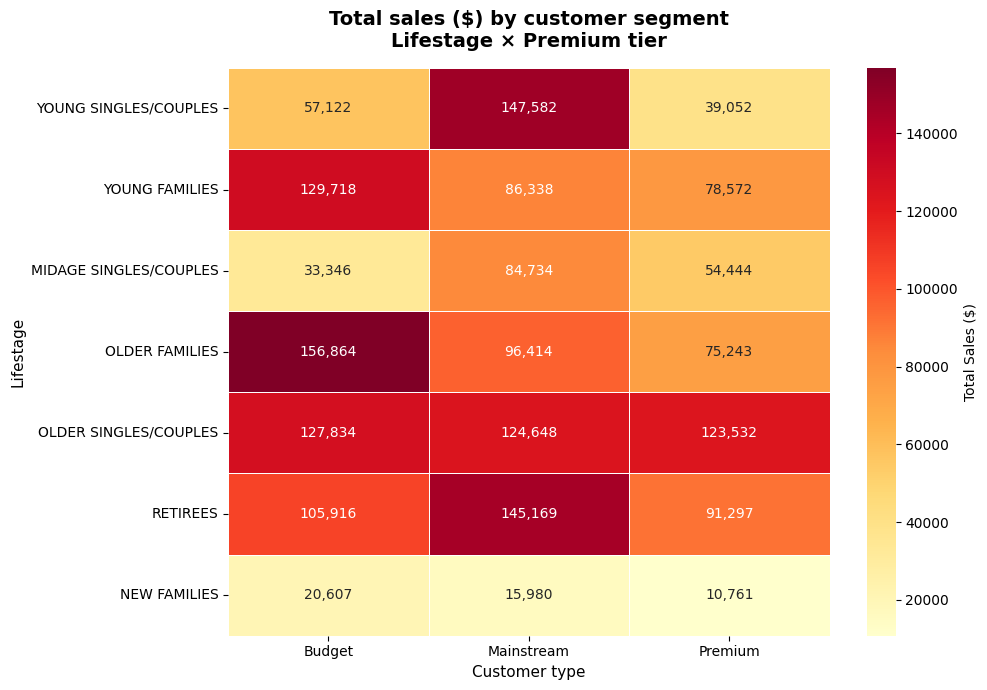

✓ Saved: chart1_sales_heatmap.png


In [9]:
#  Chart 1: Total sales by segment (heatmap)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Pivot for heatmap
heatmap_data = segment_summary.pivot(
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    values='total_sales'
)[premium_order].reindex(lifestage_order)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=',.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Total Sales ($)'},
    annot_kws={'size': 10}
)

ax.set_title('Total sales ($) by customer segment\nLifestage × Premium tier',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Customer type', fontsize=11)
ax.set_ylabel('Lifestage', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart1_sales_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: chart1_sales_heatmap.png")

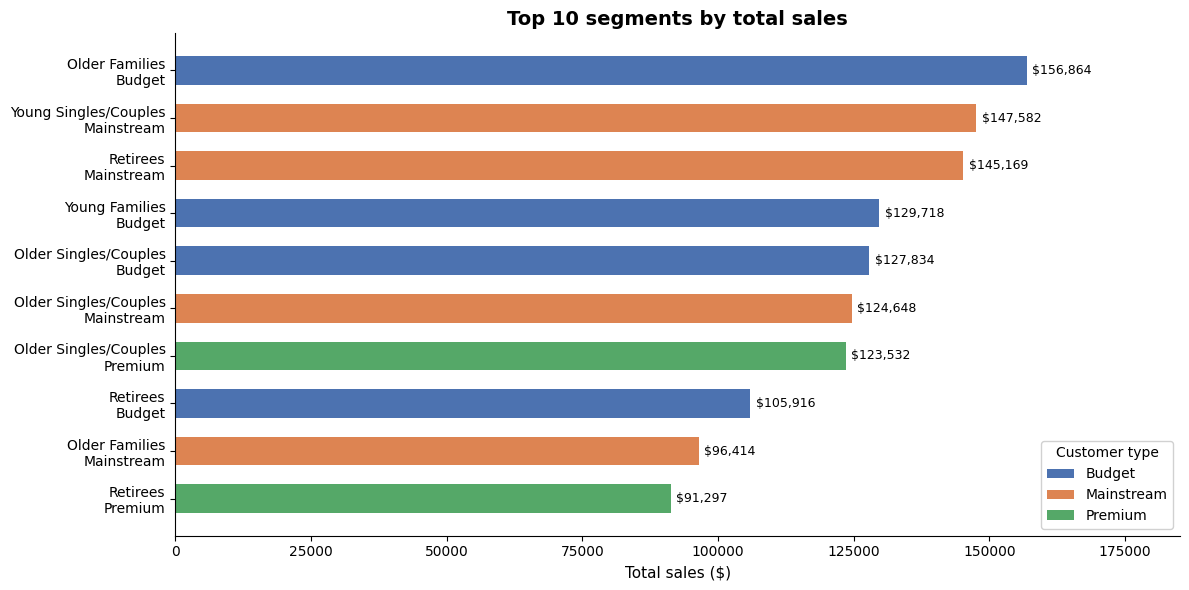

✓ Saved: chart2_sales_by_segment.png


In [12]:
# Chart 2: Total sales by segment (bar chart)
# Top 10 segments by total sales
top10 = segment_summary.sort_values('total_sales', ascending=True).tail(10)
top10['label'] = top10['LIFESTAGE'].str.title() + '\n' + top10['PREMIUM_CUSTOMER']

colors = {'Budget': '#4C72B0', 'Mainstream': '#DD8452', 'Premium': '#55A868'}
bar_colors = [colors[t] for t in top10['PREMIUM_CUSTOMER']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['label'], top10['total_sales'], color=bar_colors, height=0.6)

# Value labels
for bar, val in zip(bars, top10['total_sales']):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

ax.set_xlabel('Total sales ($)', fontsize=11)
ax.set_title('Top 10 segments by total sales', fontsize=14, fontweight='bold')
ax.set_xlim(0, top10['total_sales'].max() * 1.18)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_elements, title='Customer type',
          loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('chart2_sales_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: chart2_sales_by_segment.png")

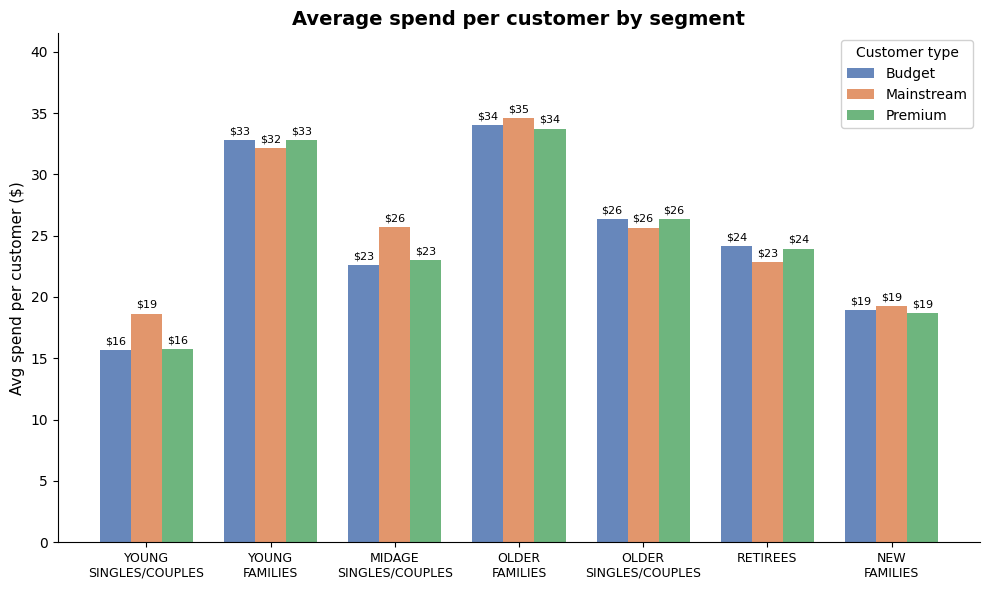

✓ Saved: chart3_avg_spend.png


In [14]:
# Chart 3 - Avg spend per customer by segment
avg_spend_pivot = segment_summary.pivot(
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    values='avg_spend_per_customer'
)[premium_order].reindex(lifestage_order)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(lifestage_order))
width = 0.25
colors_list = ['#4C72B0', '#DD8452', '#55A868']

for i, (tier, color) in enumerate(zip(premium_order, colors_list)):
    vals = avg_spend_pivot[tier].values
    bars = ax.bar(x + i * width, vals, width, label=tier, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'${val:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([l.replace(' ', '\n') for l in lifestage_order], fontsize=9)
ax.set_ylabel('Avg spend per customer ($)', fontsize=11)
ax.set_title('Average spend per customer by segment', fontsize=14, fontweight='bold')
ax.legend(title='Customer type', framealpha=0.9)
ax.set_ylim(0, segment_summary['avg_spend_per_customer'].max() * 1.2)

plt.tight_layout()
plt.savefig('chart3_avg_spend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: chart3_avg_spend.png")

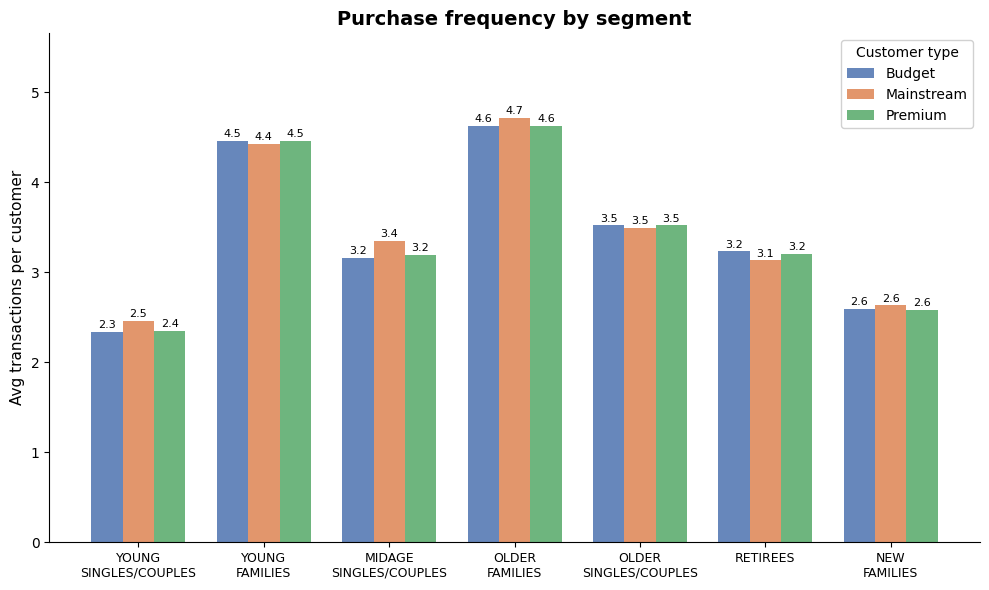

✓ Saved: chart4_purchase_frequency.png


In [15]:
# Chart 4 - Purchase frequency by Segment
freq_pivot = segment_summary.pivot(
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    values='avg_txns_per_customer'
)[premium_order].reindex(lifestage_order)

fig, ax = plt.subplots(figsize=(10, 6))

for i, (tier, color) in enumerate(zip(premium_order, colors_list)):
    vals = freq_pivot[tier].values
    bars = ax.bar(x + i * width, vals, width, label=tier, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([l.replace(' ', '\n') for l in lifestage_order], fontsize=9)
ax.set_ylabel('Avg transactions per customer', fontsize=11)
ax.set_title('Purchase frequency by segment', fontsize=14, fontweight='bold')
ax.legend(title='Customer type', framealpha=0.9)
ax.set_ylim(0, segment_summary['avg_txns_per_customer'].max() * 1.2)

plt.tight_layout()
plt.savefig('chart4_purchase_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: chart4_purchase_frequency.png")

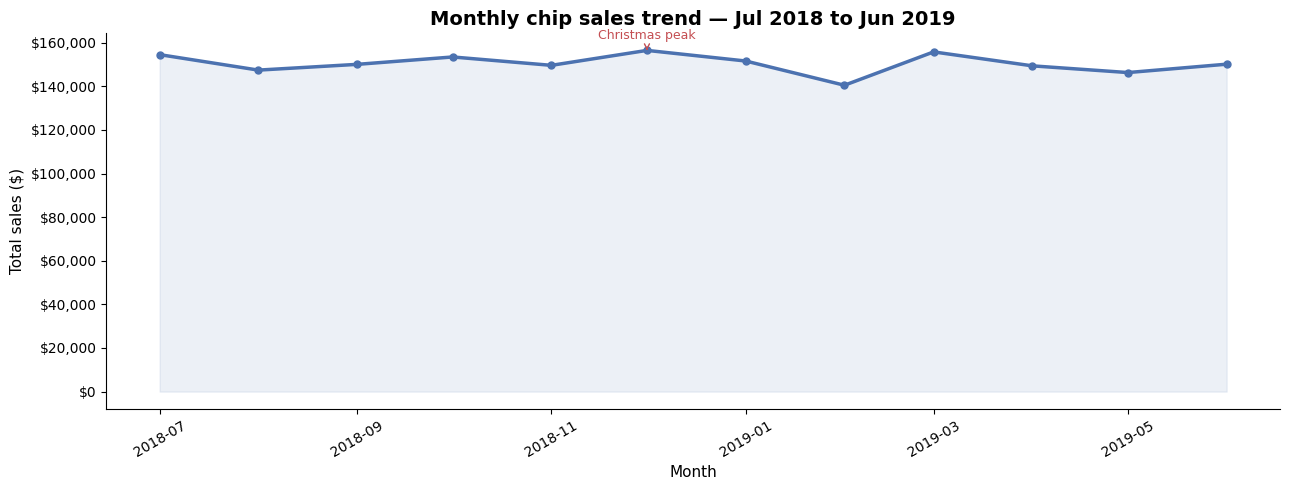

✓ Saved: chart5_monthly_trend.png


In [16]:
# Chart 5 - Monthly Sales Trend
monthly_sales = (merged
    .groupby(merged['DATE'].dt.to_period('M'))['TOT_SALES']
    .sum()
    .reset_index()
)
monthly_sales['DATE'] = monthly_sales['DATE'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(monthly_sales['DATE'], monthly_sales['TOT_SALES'],
        color='#4C72B0', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(monthly_sales['DATE'], monthly_sales['TOT_SALES'],
                alpha=0.1, color='#4C72B0')

# Highlight December peak
dec = monthly_sales[monthly_sales['DATE'].dt.month == 12]
if not dec.empty:
    ax.annotate('Christmas peak',
                xy=(dec['DATE'].values[0], dec['TOT_SALES'].values[0]),
                xytext=(dec['DATE'].values[0], dec['TOT_SALES'].values[0] + 5000),
                ha='center', fontsize=9, color='#C44E52',
                arrowprops=dict(arrowstyle='->', color='#C44E52'))

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total sales ($)', fontsize=11)
ax.set_title('Monthly chip sales trend — Jul 2018 to Jun 2019',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('chart5_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: chart5_monthly_trend.png")

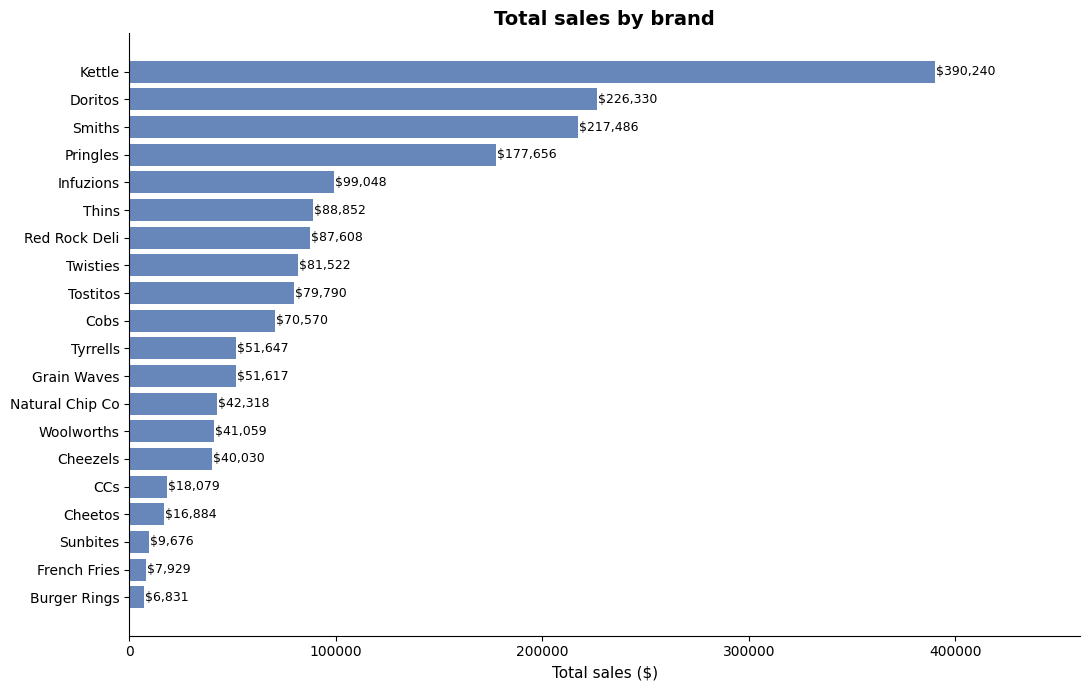

✓ Saved: chart6_brand_sales.png


In [17]:
# Chart 6 - Top brands by total Sales
brand_sales = (merged
    .groupby('BRAND')['TOT_SALES']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(brand_sales.index, brand_sales.values, color='#4C72B0', alpha=0.85)

for bar, val in zip(bars, brand_sales.values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

ax.set_xlabel('Total sales ($)', fontsize=11)
ax.set_title('Total sales by brand', fontsize=14, fontweight='bold')
ax.set_xlim(0, brand_sales.max() * 1.18)

plt.tight_layout()
plt.savefig('chart6_brand_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: chart6_brand_sales.png")

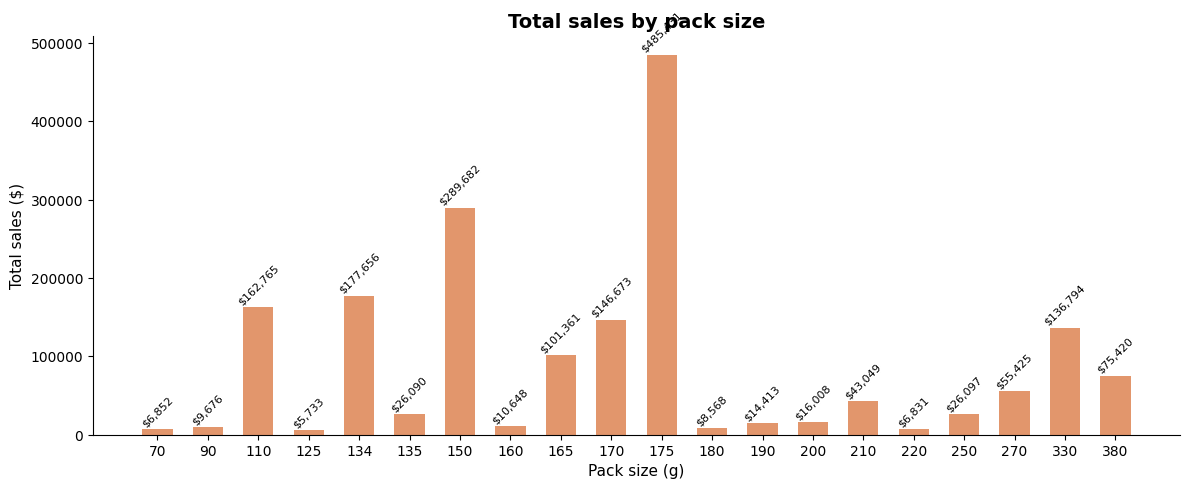

✓ Saved: chart7_pack_size_sales.png


In [18]:
# Chart 7 - Sales by Pack size
pack_sales = (merged
    .groupby('PACK_SIZE')['TOT_SALES']
    .sum()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(pack_sales.index.astype(str), pack_sales.values,
              color='#DD8452', alpha=0.85, width=0.6)

for bar, val in zip(bars, pack_sales.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=8, rotation=45)

ax.set_xlabel('Pack size (g)', fontsize=11)
ax.set_ylabel('Total sales ($)', fontsize=11)
ax.set_title('Total sales by pack size', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chart7_pack_size_sales.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: chart7_pack_size_sales.png")

In [20]:
# Calculate average unit price by segment
avg_price = (merged
    .groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])
    .agg(avg_unit_price = ('UNIT_PRICE', 'mean'))
    .reset_index()
    .round(2)
)

print("✓ avg_price calculated")
print(avg_price.sort_values('avg_unit_price', ascending=False))

✓ avg_price calculated
                 LIFESTAGE PREMIUM_CUSTOMER  avg_unit_price
19   YOUNG SINGLES/COUPLES       Mainstream            4.07
1   MIDAGE SINGLES/COUPLES       Mainstream            3.99
4             NEW FAMILIES       Mainstream            3.92
12                RETIREES           Budget            3.92
3             NEW FAMILIES           Budget            3.92
14                RETIREES          Premium            3.92
11   OLDER SINGLES/COUPLES          Premium            3.89
9    OLDER SINGLES/COUPLES           Budget            3.88
5             NEW FAMILIES          Premium            3.87
13                RETIREES       Mainstream            3.84
10   OLDER SINGLES/COUPLES       Mainstream            3.81
2   MIDAGE SINGLES/COUPLES          Premium            3.77
17          YOUNG FAMILIES          Premium            3.76
15          YOUNG FAMILIES           Budget            3.76
6           OLDER FAMILIES           Budget            3.75
0   MIDAGE SINGLE

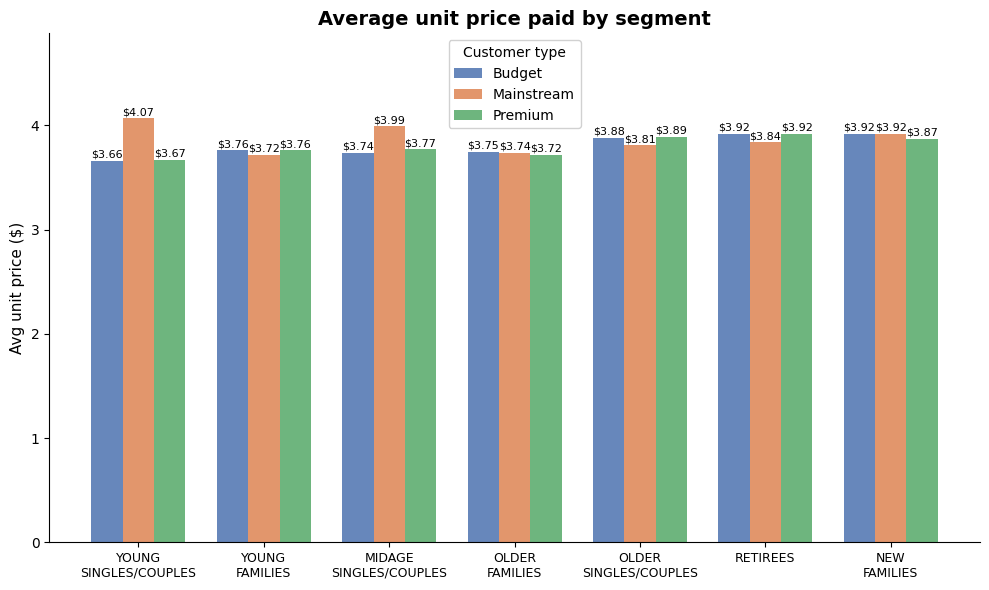

✓ Saved: chart8_avg_unit_price.png


In [21]:
# Chart 8 - Avg unit price by segment
price_pivot = avg_price.pivot(
    index='LIFESTAGE',
    columns='PREMIUM_CUSTOMER',
    values='avg_unit_price'
)[premium_order].reindex(lifestage_order)

fig, ax = plt.subplots(figsize=(10, 6))

for i, (tier, color) in enumerate(zip(premium_order, colors_list)):
    vals = price_pivot[tier].values
    bars = ax.bar(x + i * width, vals, width, label=tier, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'${val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([l.replace(' ', '\n') for l in lifestage_order], fontsize=9)
ax.set_ylabel('Avg unit price ($)', fontsize=11)
ax.set_title('Average unit price paid by segment', fontsize=14, fontweight='bold')
ax.legend(title='Customer type', framealpha=0.9)
ax.set_ylim(0, avg_price['avg_unit_price'].max() * 1.2)

plt.tight_layout()
plt.savefig('chart8_avg_unit_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: chart8_avg_unit_price.png")

## Phase 6 Summary

| Chart | File | Key insight |
|---|---|---|
| 1 — Sales heatmap | chart1_sales_heatmap.png | [fill in] |
| 2 — Sales by segment | chart2_sales_by_segment.png | [fill in] |
| 3 — Avg spend per customer | chart3_avg_spend.png | [fill in] |
| 4 — Purchase frequency | chart4_purchase_frequency.png | [fill in] |
| 5 — Monthly trend | chart5_monthly_trend.png | [fill in] |
| 6 — Brand sales | chart6_brand_sales.png | [fill in] |
| 7 — Pack size sales | chart7_pack_size_sales.png | [fill in] |
| 8 — Avg unit price | chart8_avg_unit_price.png | [fill in] |

**Next:** Phase 7 — Strategic recommendation for Julia